In [ ]:
!pip install opencv-python numpy scipy pandas matplotlib
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


FPS: 29.85632359221524
Frames: 783
Duration: 26.2256
Processed frames: 783
Face frames: 783

========== RESULTS ==========
HR FFT before: 73.2 bpm
HR Peak before: 73.0 bpm
Motion dominant frequency: 0.878 Hz
HR FFT after: 73.2 bpm
HR Peak after: 73.0 bpm
FINAL HR: 73.1 bpm
Final HR method: average_fft_peak
CSV: rppg_final_outputs_v2/rppg_results.csv
Annotated video: rppg_final_outputs_v2/annotated_output.mp4



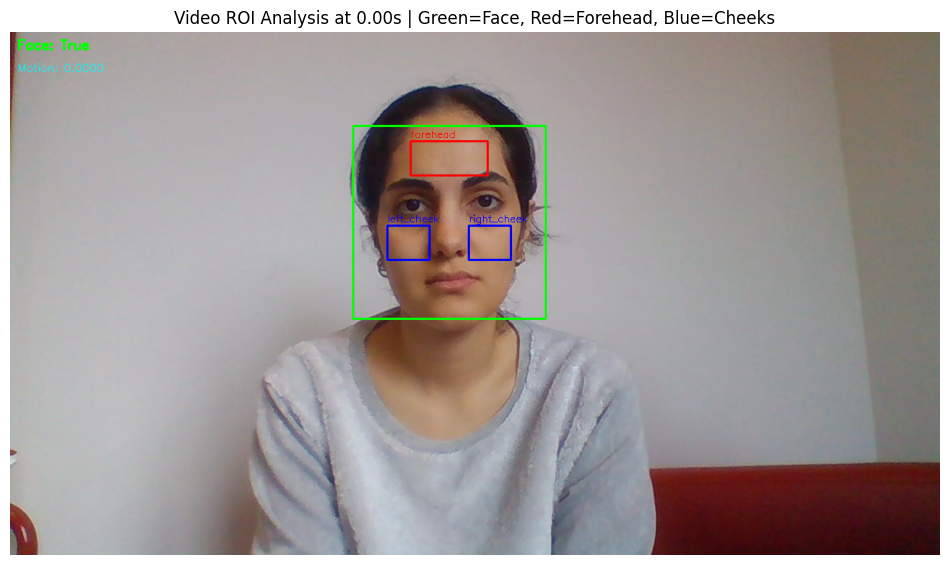

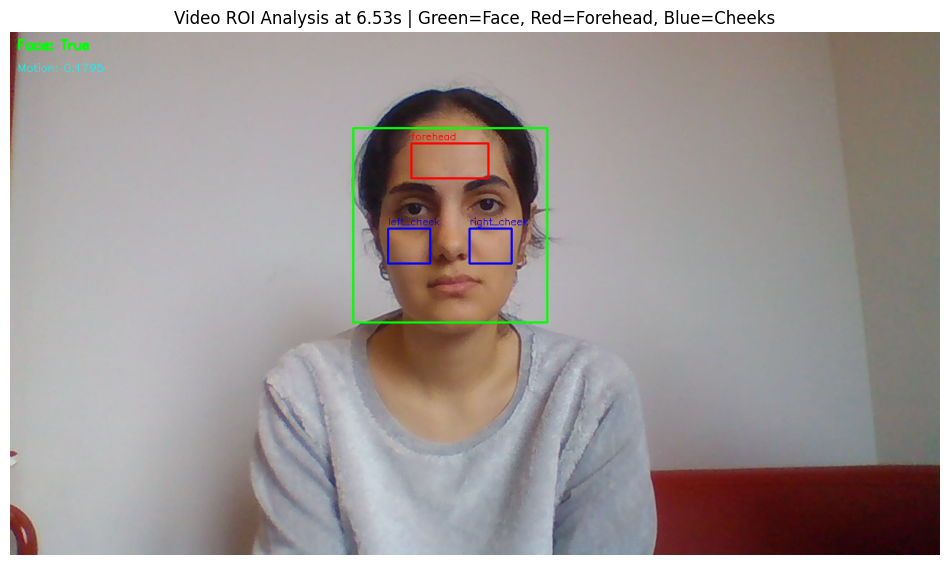

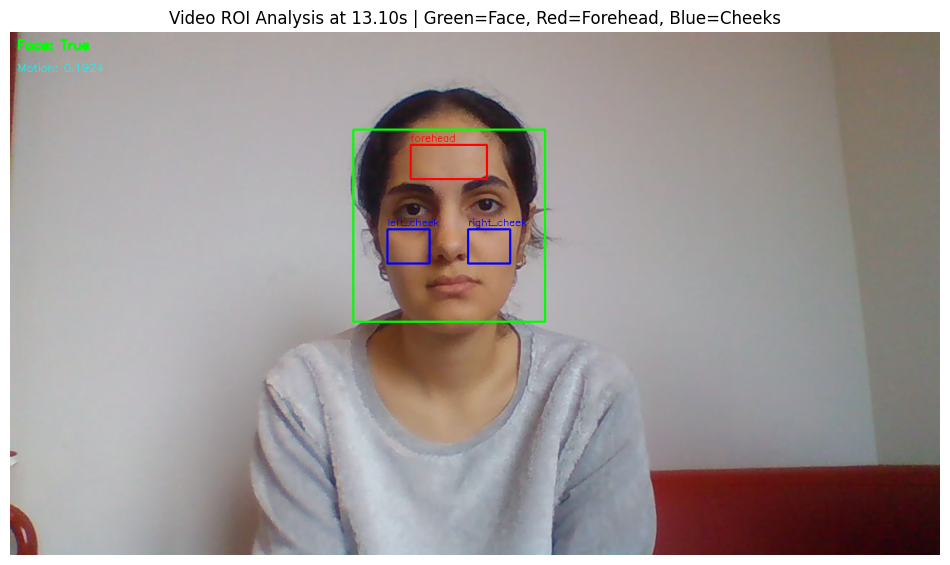

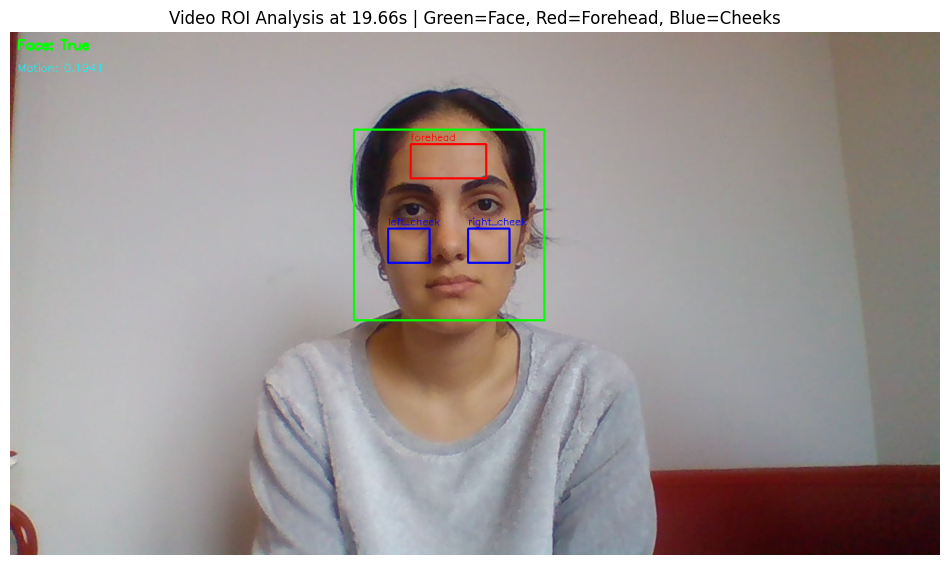

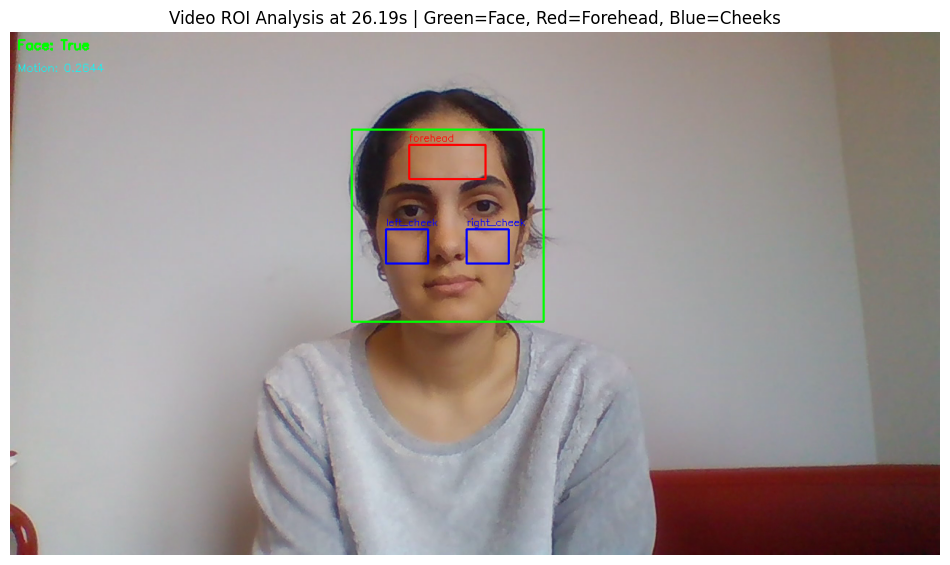

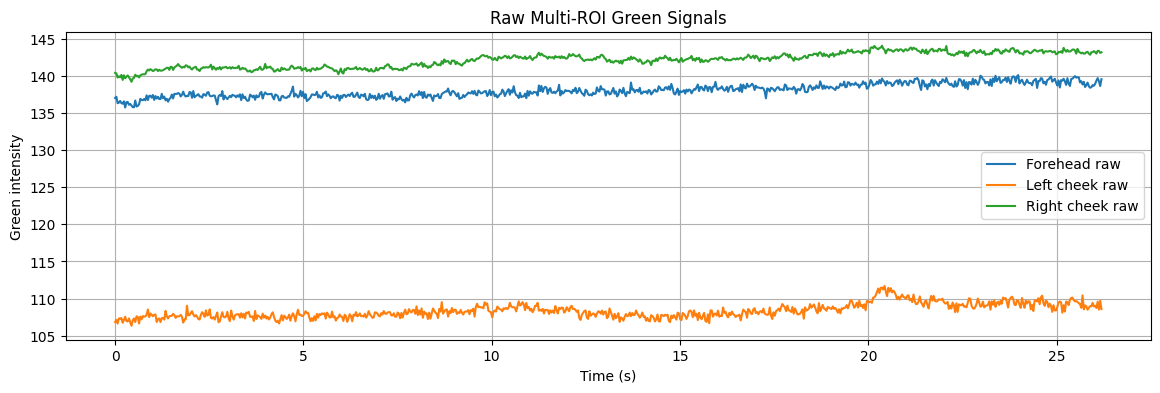

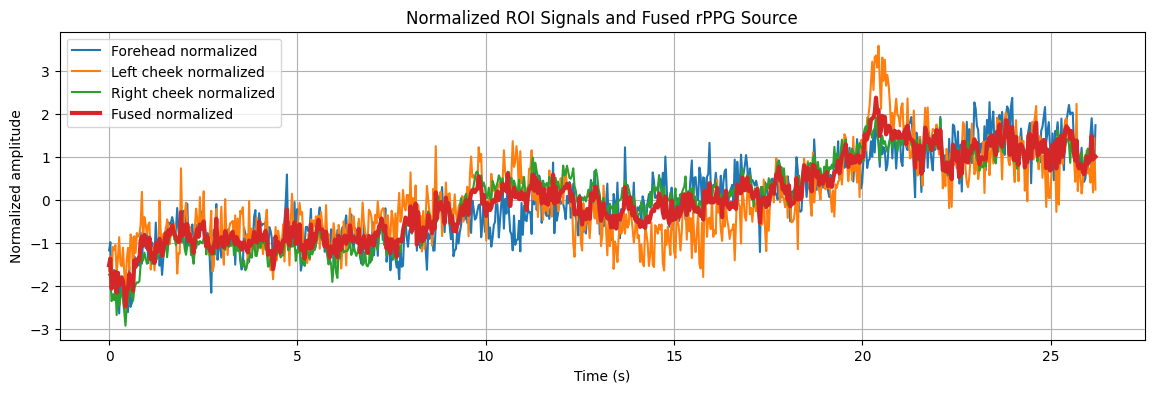

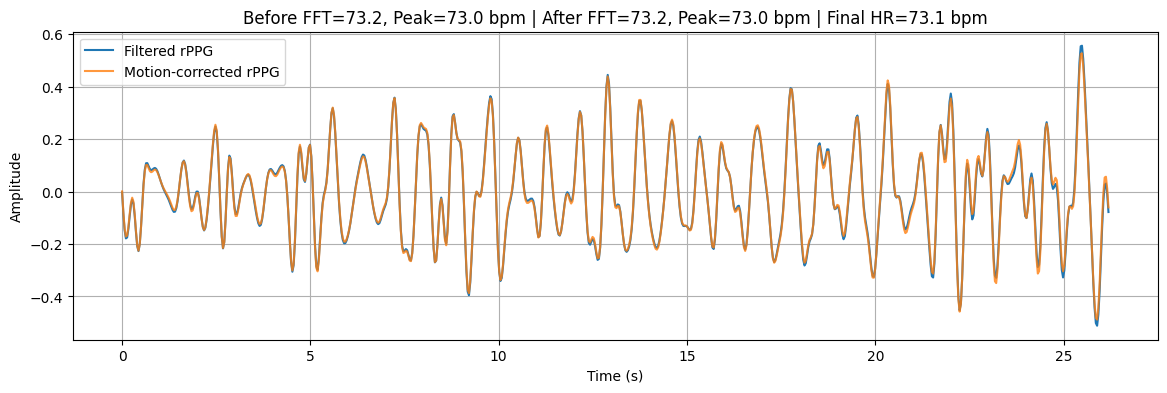

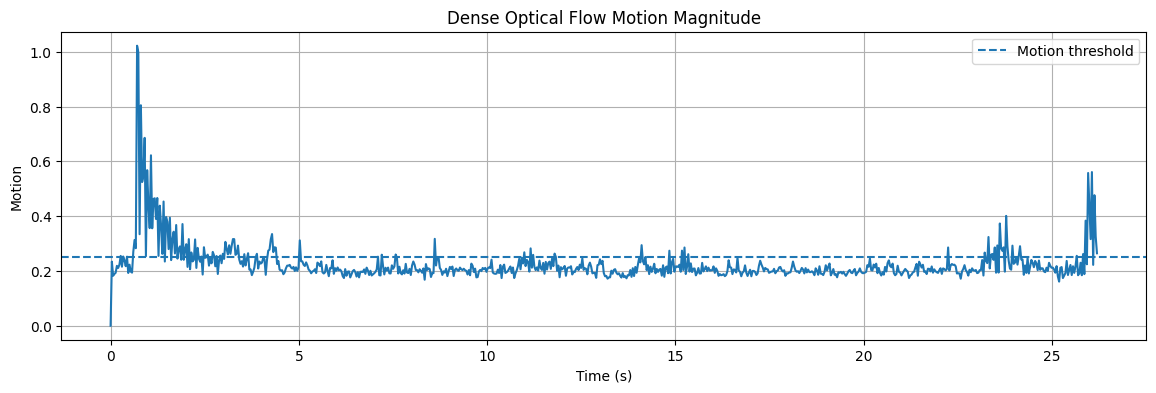

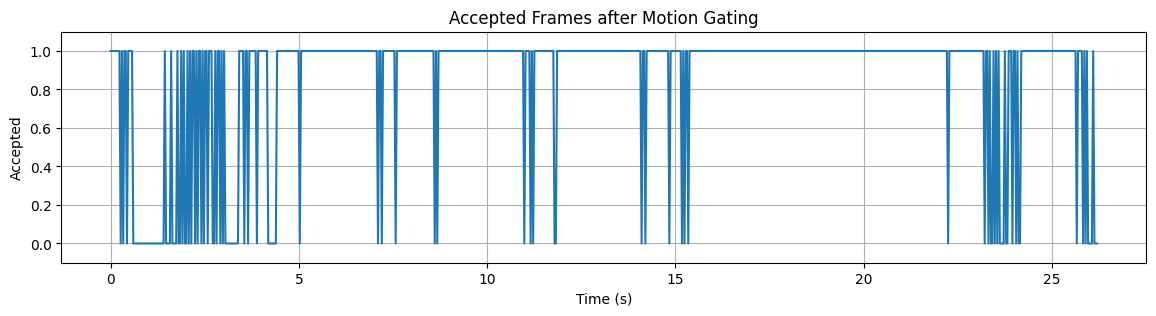

Saved summary: rppg_final_outputs_v2/summary.json
Done.


In [ ]:

import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks, welch, iirnotch

# =========================
# CONFIG
# =========================

VIDEO_PATH = "test_video.mp4"
OUTPUT_DIR = "rppg_final_outputs_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_BPM = 40
MAX_BPM = 220

MOTION_GATE_PERCENTILE = 85
NOTCH_Q = 30.0

# =========================
# FACE DETECTOR
# =========================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# =========================
# ROI FUNCTIONS
# =========================

def get_face_rois(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(100, 100)
    )

    if len(faces) == 0:
        return None, {}

    faces = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)
    x, y, w, h = faces[0]

    face_box = (x, y, w, h)

    rois = {
        "forehead": (
            x + int(0.30 * w),
            y + int(0.08 * h),
            int(0.40 * w),
            int(0.18 * h)
        ),

        # cheek ROIs moved slightly lower and made slightly shorter
        "left_cheek": (
            x + int(0.18 * w),
            y + int(0.52 * h),
            int(0.22 * w),
            int(0.18 * h)
        ),

        "right_cheek": (
            x + int(0.60 * w),
            y + int(0.52 * h),
            int(0.22 * w),
            int(0.18 * h)
        )
    }

    fixed_rois = {}

    for name, roi in rois.items():
        rx, ry, rw, rh = roi

        rx = max(0, rx)
        ry = max(0, ry)
        rw = max(1, min(rw, frame.shape[1] - rx))
        rh = max(1, min(rh, frame.shape[0] - ry))

        fixed_rois[name] = (rx, ry, rw, rh)

    return face_box, fixed_rois


def extract_multi_roi_green(frame, rois):
    signals = {}

    for name, roi in rois.items():
        x, y, w, h = roi
        roi_img = frame[y:y+h, x:x+w]

        if roi_img.size == 0:
            signals[name] = np.nan
        else:
            signals[name] = float(np.mean(roi_img[:, :, 1]))

    return signals

# =========================
# SIGNAL PROCESSING
# =========================

def normalize_signal(signal):
    signal = np.asarray(signal, dtype=float)

    mean = np.nanmean(signal)
    std = np.nanstd(signal)

    if std < 1e-8:
        return signal - mean

    return (signal - mean) / std


def robust_multi_roi_fusion(df):
    """
    Normalize each ROI separately, then average.
    This avoids raw brightness imbalance between forehead and cheeks.
    """

    roi_cols = [
        "green_forehead",
        "green_left_cheek",
        "green_right_cheek"
    ]

    normalized_rois = []

    for col in roi_cols:
        sig = df[col].interpolate(limit_direction="both").values
        sig_norm = normalize_signal(sig)
        normalized_rois.append(sig_norm)

        df[col + "_norm"] = sig_norm

    stacked = np.vstack(normalized_rois)
    fused_norm = np.nanmean(stacked, axis=0)

    return fused_norm, df


def bandpass_filter(signal, fs, min_bpm=40, max_bpm=220):
    signal = np.asarray(signal, dtype=float)

    lowcut = min_bpm / 60.0
    highcut = max_bpm / 60.0

    try:
        b, a = butter(
            4,
            [lowcut, highcut],
            btype="band",
            fs=fs
        )

        padlen = 3 * max(len(a), len(b))

        if len(signal) <= padlen:
            return signal

        return filtfilt(b, a, signal)

    except Exception as e:
        print("Bandpass error:", e)
        return signal


def estimate_hr_fft(signal, fs, min_bpm=40, max_bpm=220):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < int(fs * 4):
        return None

    signal = signal - np.mean(signal)

    freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
    mag = np.abs(np.fft.rfft(signal))

    mask = (
        (freqs >= min_bpm / 60.0) &
        (freqs <= max_bpm / 60.0)
    )

    if not np.any(mask):
        return None

    valid_freqs = freqs[mask]
    valid_mag = mag[mask]

    return float(valid_freqs[np.argmax(valid_mag)] * 60.0)


def estimate_hr_peak(signal, fs, min_bpm=40, max_bpm=220):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < int(fs * 4):
        return None

    signal = signal - np.mean(signal)

    # less aggressive peak detection
    min_distance = int(fs * 0.45)
    prominence = max(0.2, 0.35 * np.std(signal))

    peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    if len(peaks) < 2:
        return None

    intervals = np.diff(peaks) / fs
    avg_interval = np.mean(intervals)

    if avg_interval <= 0:
        return None

    hr = 60.0 / avg_interval

    if hr < min_bpm or hr > max_bpm:
        return None

    return float(hr)


def select_final_hr(hr_fft, hr_peak):
    """
    Smart final HR selection.
    If FFT and Peak disagree strongly, trust FFT.
    Otherwise average them.
    """

    if hr_fft is None and hr_peak is None:
        return None, "none"

    if hr_fft is None:
        return hr_peak, "peak_only"

    if hr_peak is None:
        return hr_fft, "fft_only"

    if abs(hr_fft - hr_peak) > 15:
        return hr_fft, "fft_selected_due_to_disagreement"

    return (hr_fft + hr_peak) / 2.0, "average_fft_peak"

# =========================
# MOTION FUNCTIONS
# =========================

def compute_motion(prev_gray, curr_gray, roi):
    if prev_gray is None or curr_gray is None or roi is None:
        return 0.0

    x, y, w, h = roi

    prev_roi = prev_gray[y:y+h, x:x+w]
    curr_roi = curr_gray[y:y+h, x:x+w]

    if prev_roi.size == 0 or curr_roi.size == 0:
        return 0.0

    flow = cv2.calcOpticalFlowFarneback(
        prev_roi,
        curr_roi,
        None,
        0.5,
        3,
        15,
        3,
        5,
        1.2,
        0
    )

    mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    return float(np.mean(mag))


def dominant_motion_frequency(motion_signal, fs):
    motion_signal = np.asarray(motion_signal, dtype=float)

    if len(motion_signal) < int(fs * 4):
        return None

    motion_signal = normalize_signal(motion_signal)

    freqs, psd = welch(
        motion_signal,
        fs=fs,
        nperseg=min(len(motion_signal), int(fs * 8))
    )

    mask = (freqs >= 0.4) & (freqs <= 4.0)

    if not np.any(mask):
        return None

    valid_freqs = freqs[mask]
    valid_psd = psd[mask]

    return float(valid_freqs[np.argmax(valid_psd)])


def frequency_cancellation(signal, fs, motion_freq):
    if motion_freq is None:
        return signal

    if motion_freq <= 0 or motion_freq >= fs / 2:
        return signal

    try:
        b, a = iirnotch(
            w0=motion_freq,
            Q=NOTCH_Q,
            fs=fs
        )

        padlen = 3 * max(len(a), len(b))

        if len(signal) <= padlen:
            return signal

        return filtfilt(b, a, signal)

    except Exception as e:
        print("Notch error:", e)
        return signal


def safe_fmt(x):
    return "--" if x is None else f"{x:.1f}"

# =========================
# MAIN VIDEO PROCESSING
# =========================

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Video not found. Check VIDEO_PATH.")

fps = cap.get(cv2.CAP_PROP_FPS)

if fps <= 0:
    fps = 30.0

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

print("FPS:", fps)
print("Frames:", frame_count)
print("Duration:", duration)

ret, first_frame = cap.read()

if not ret:
    raise RuntimeError("Could not read first frame.")

height, width = first_frame.shape[:2]

annotated_path = os.path.join(OUTPUT_DIR, "annotated_output.mp4")
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    annotated_path,
    fourcc,
    fps,
    (width, height)
)

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

rows = []
sample_frames = []

sample_ids = [
    0,
    int(frame_count * 0.25),
    int(frame_count * 0.50),
    int(frame_count * 0.75),
    frame_count - 1
]

prev_gray = None
frame_idx = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    time_sec = frame_idx / fps
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    face_box, rois = get_face_rois(frame)

    face_found = False
    motion = np.nan
    signals = {}

    annotated = frame.copy()

    if face_box is not None:
        face_found = True

        signals = extract_multi_roi_green(frame, rois)

        # optical flow on full face box
        motion = compute_motion(prev_gray, gray, face_box)

        x, y, w, h = face_box
        cv2.rectangle(
            annotated,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            2
        )

        colors = {
            "forehead": (0, 0, 255),
            "left_cheek": (255, 0, 0),
            "right_cheek": (255, 0, 0)
        }

        for name, roi in rois.items():
            rx, ry, rw, rh = roi

            cv2.rectangle(
                annotated,
                (rx, ry),
                (rx+rw, ry+rh),
                colors[name],
                2
            )

            cv2.putText(
                annotated,
                name,
                (rx, max(20, ry - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                colors[name],
                1
            )

    rows.append({
        "frame": frame_idx,
        "time_sec": time_sec,
        "face_found": face_found,
        "green_forehead": signals.get("forehead", np.nan),
        "green_left_cheek": signals.get("left_cheek", np.nan),
        "green_right_cheek": signals.get("right_cheek", np.nan),
        "motion_magnitude": motion
    })

    cv2.putText(
        annotated,
        f"Face: {face_found}",
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0) if face_found else (0, 0, 255),
        2
    )

    cv2.putText(
        annotated,
        f"Motion: {motion:.4f}" if not np.isnan(motion) else "Motion: --",
        (10, 55),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 0),
        1
    )

    writer.write(annotated)

    if frame_idx in sample_ids:
        sample_frames.append(
            (time_sec, cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        )

    prev_gray = gray
    frame_idx += 1

cap.release()
writer.release()

# =========================
# DATAFRAME
# =========================

df = pd.DataFrame(rows)

print("Processed frames:", len(df))
print("Face frames:", int(df["face_found"].sum()))

# =========================
# MOTION CLEANING
# =========================

df["motion_interp"] = (
    df["motion_magnitude"]
    .interpolate(limit_direction="both")
    .fillna(0.0)
)

motion_threshold = float(
    np.nanpercentile(
        df["motion_interp"],
        MOTION_GATE_PERCENTILE
    )
)

df["motion_ok"] = df["motion_interp"] <= motion_threshold

# =========================
# NORMALIZED ROI FUSION
# =========================

fused_norm, df = robust_multi_roi_fusion(df)

# apply motion gating to fused signal
fused_used = pd.Series(fused_norm).copy()
fused_used[~df["motion_ok"].values] = np.nan
fused_used = fused_used.interpolate(limit_direction="both")

t = df["time_sec"].values
motion_signal = df["motion_interp"].values
raw_signal = fused_used.values

# =========================
# FILTERING + MOTION CANCELLATION
# =========================

filtered = bandpass_filter(
    raw_signal,
    fps,
    MIN_BPM,
    MAX_BPM
)

motion_freq = dominant_motion_frequency(
    motion_signal,
    fps
)

corrected = frequency_cancellation(
    filtered,
    fps,
    motion_freq
)

# =========================
# HR ESTIMATION
# =========================

hr_fft_before = estimate_hr_fft(
    filtered,
    fps,
    MIN_BPM,
    MAX_BPM
)

hr_peak_before = estimate_hr_peak(
    filtered,
    fps,
    MIN_BPM,
    MAX_BPM
)

hr_fft_after = estimate_hr_fft(
    corrected,
    fps,
    MIN_BPM,
    MAX_BPM
)

hr_peak_after = estimate_hr_peak(
    corrected,
    fps,
    MIN_BPM,
    MAX_BPM
)

final_hr, final_hr_method = select_final_hr(
    hr_fft_after,
    hr_peak_after
)

# =========================
# STORE SIGNALS
# =========================

df["fused_normalized_signal"] = fused_norm
df["signal_used"] = raw_signal
df["filtered_rppg"] = filtered
df["corrected_rppg"] = corrected

# =========================
# SAVE CSV
# =========================

csv_path = os.path.join(OUTPUT_DIR, "rppg_results.csv")
df.to_csv(csv_path, index=False)

# =========================
# PRINT RESULTS
# =========================

print("\n========== RESULTS ==========")
print("HR FFT before:", safe_fmt(hr_fft_before), "bpm")
print("HR Peak before:", safe_fmt(hr_peak_before), "bpm")
print("Motion dominant frequency:", "--" if motion_freq is None else f"{motion_freq:.3f}", "Hz")
print("HR FFT after:", safe_fmt(hr_fft_after), "bpm")
print("HR Peak after:", safe_fmt(hr_peak_after), "bpm")
print("FINAL HR:", safe_fmt(final_hr), "bpm")
print("Final HR method:", final_hr_method)
print("CSV:", csv_path)
print("Annotated video:", annotated_path)
print("=============================\n")

# =========================
# SAVE SUMMARY
# =========================

summary = {
    "video_path": VIDEO_PATH,
    "fps": float(fps),
    "frames": int(frame_count),
    "duration_sec": float(duration),
    "face_frames": int(df["face_found"].sum()),
    "motion_threshold": float(motion_threshold),
    "motion_dominant_frequency_hz": None if motion_freq is None else float(motion_freq),
    "hr_fft_before_bpm": None if hr_fft_before is None else float(hr_fft_before),
    "hr_peak_before_bpm": None if hr_peak_before is None else float(hr_peak_before),
    "hr_fft_after_bpm": None if hr_fft_after is None else float(hr_fft_after),
    "hr_peak_after_bpm": None if hr_peak_after is None else float(hr_peak_after),
    "final_hr_bpm": None if final_hr is None else float(final_hr),
    "final_hr_method": final_hr_method
}

summary_path = os.path.join(OUTPUT_DIR, "summary.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

# =========================
# SAMPLE ROI FRAMES
# =========================

for time_sec, img in sample_frames:
    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.title(
        f"Video ROI Analysis at {time_sec:.2f}s | "
        "Green=Face, Red=Forehead, Blue=Cheeks"
    )
    plt.axis("off")
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"sample_roi_{time_sec:.1f}s.png"
        ),
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

# =========================
# PLOT 1: RAW ROI GREEN SIGNALS
# =========================

plt.figure(figsize=(14, 4))
plt.plot(t, df["green_forehead"], label="Forehead raw")
plt.plot(t, df["green_left_cheek"], label="Left cheek raw")
plt.plot(t, df["green_right_cheek"], label="Right cheek raw")

plt.title("Raw Multi-ROI Green Signals")
plt.xlabel("Time (s)")
plt.ylabel("Green intensity")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_raw_multi_roi_signals.png"
    ),
    dpi=200
)

plt.show()

# =========================
# PLOT 2: NORMALIZED ROI SIGNALS
# =========================

plt.figure(figsize=(14, 4))
plt.plot(t, df["green_forehead_norm"], label="Forehead normalized")
plt.plot(t, df["green_left_cheek_norm"], label="Left cheek normalized")
plt.plot(t, df["green_right_cheek_norm"], label="Right cheek normalized")
plt.plot(t, df["fused_normalized_signal"], linewidth=3, label="Fused normalized")

plt.title("Normalized ROI Signals and Fused rPPG Source")
plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_normalized_fused_roi_signal.png"
    ),
    dpi=200
)

plt.show()

# =========================
# PLOT 3: FILTERED AND CORRECTED RPPG
# =========================

plt.figure(figsize=(14, 4))
plt.plot(t, filtered, label="Filtered rPPG")
plt.plot(t, corrected, label="Motion-corrected rPPG", alpha=0.8)

plt.title(
    f"Before FFT={safe_fmt(hr_fft_before)}, "
    f"Peak={safe_fmt(hr_peak_before)} bpm | "
    f"After FFT={safe_fmt(hr_fft_after)}, "
    f"Peak={safe_fmt(hr_peak_after)} bpm | "
    f"Final HR={safe_fmt(final_hr)} bpm"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_filtered_corrected_rppg.png"
    ),
    dpi=200
)

plt.show()

# =========================
# PLOT 4: MOTION
# =========================

plt.figure(figsize=(14, 4))
plt.plot(t, motion_signal)
plt.axhline(motion_threshold, linestyle="--", label="Motion threshold")

plt.title("Dense Optical Flow Motion Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Motion")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_motion.png"
    ),
    dpi=200
)

plt.show()

# =========================
# PLOT 5: ACCEPTED FRAMES
# =========================

plt.figure(figsize=(14, 3))
plt.plot(t, df["motion_ok"].astype(int))

plt.title("Accepted Frames after Motion Gating")
plt.xlabel("Time (s)")
plt.ylabel("Accepted")
plt.ylim(-0.1, 1.1)
plt.grid(True)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_accepted_frames.png"
    ),
    dpi=200
)

plt.show()

print("Saved summary:", summary_path)
print("Done.")